In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_samples
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [2]:
df = pd.read_csv("data/credit_card.csv")

print("Shape:", df.shape)

df.head()

Shape: (660, 7)


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,102487.143050,2.025961,0.974730,1.450667,0.200438
1,2,38414,49898.381255,3.051377,0.091629,9.831703,9.090216
2,3,17341,50303.242886,6.963332,0.977077,2.946968,4.185461
3,4,40496,30024.937358,4.794870,1.158414,1.011002,4.118329
4,5,47437,98738.336448,5.894122,0.048569,12.202551,2.653637


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sl_No                660 non-null    int64  
 1   Customer Key         660 non-null    int64  
 2   Avg_Credit_Limit     660 non-null    float64
 3   Total_Credit_Cards   660 non-null    float64
 4   Total_visits_bank    660 non-null    float64
 5   Total_visits_online  660 non-null    float64
 6   Total_calls_made     660 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 36.2 KB


In [4]:
df.isnull().sum()

Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

In [5]:
# Remove columns that identify customers but do not describe behavior

df = df.drop(columns=["Sl_No", "Customer Key"])

df.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,102487.143050,2.025961,0.974730,1.450667,0.200438
1,49898.381255,3.051377,0.091629,9.831703,9.090216
2,50303.242886,6.963332,0.977077,2.946968,4.185461
3,30024.937358,4.794870,1.158414,1.011002,4.118329
4,98738.336448,5.894122,0.048569,12.202551,2.653637


In [6]:
print(df.shape)
print(df.columns.tolist())

(660, 5)
['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']


In [7]:
# Count outliers using the IQR method

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

outlier_mask = (df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))

print("Rows with at least one outlier:", outlier_mask.any(axis=1).sum())

Rows with at least one outlier: 49


In [8]:
# Remove rows containing IQR outliers

df_clean = df[~outlier_mask.any(axis=1)]

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (660, 5)
Cleaned shape: (611, 5)


In [9]:
# Standardize features

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_clean)

scaled_df = pd.DataFrame(scaled_data, columns=df_clean.columns)

scaled_df.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,3.612792,-1.253992,-0.986911,-0.315206,-1.257221
1,1.145783,1.356411,-0.985444,0.629685,0.139937
2,0.187120,0.209939,-0.872035,-0.592847,0.116400
3,-0.244387,-0.736133,-1.596506,-0.609428,1.534543
4,-0.388721,-0.842915,-1.596506,-0.542300,-1.025807


In [10]:
print(scaled_df.mean().round(2))
print()
print(scaled_df.std().round(2))

Avg_Credit_Limit      -0.0
Total_Credit_Cards    -0.0
Total_visits_bank     -0.0
Total_visits_online   -0.0
Total_calls_made       0.0
dtype: float64

Avg_Credit_Limit       1.0
Total_Credit_Cards     1.0
Total_visits_bank      1.0
Total_visits_online    1.0
Total_calls_made       1.0
dtype: float64


c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

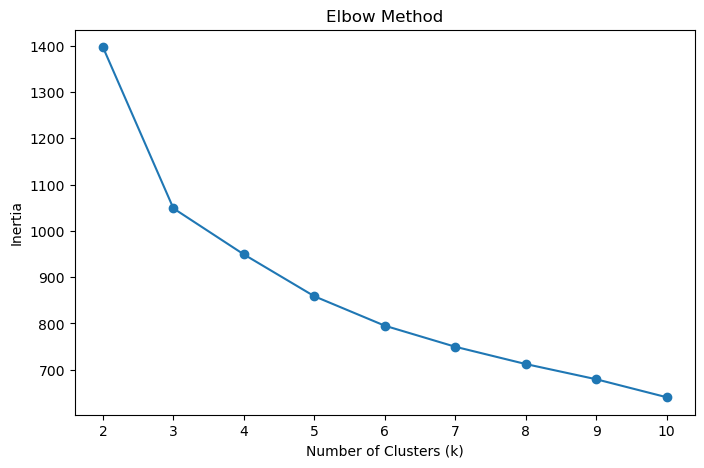

In [11]:
# Elbow Method to find a good value for k

inertia_values = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    kmeans.fit(scaled_df)

    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia_values, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.show()

In [12]:
results = []

for k in range(2, 11):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = kmeans.fit_predict(scaled_df)

    silhouette = silhouette_score(scaled_df, labels)

    davies = davies_bouldin_score(scaled_df, labels)

    results.append([k, silhouette, davies])

results_df = pd.DataFrame(
    results, columns=["k", "Silhouette Score", "Davies-Bouldin Score"]
)

results_df

c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

,k,Silhouette Score,Davies-Bouldin Score
0,2,0.477012,0.820097
1,3,0.378131,1.135367
2,4,0.316045,1.333536
3,5,0.228427,1.578998
4,6,0.212506,1.679287
5,7,0.202649,1.593062
6,8,0.197385,1.564407
7,9,0.194383,1.560299
8,10,0.202444,1.440764


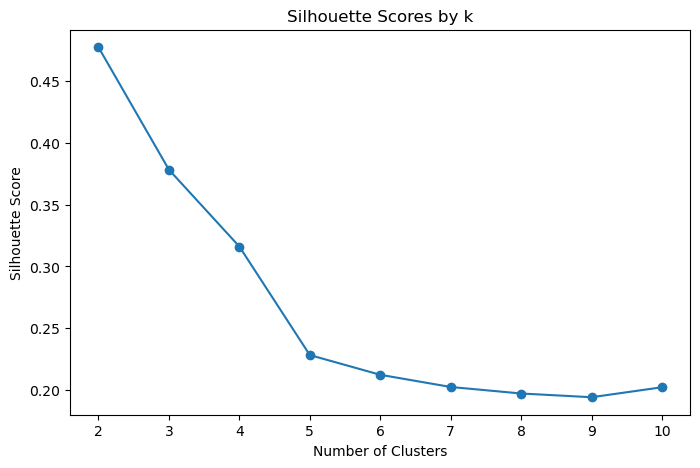

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(results_df["k"], results_df["Silhouette Score"], marker="o")

plt.title("Silhouette Scores by k")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.show()

In [14]:
# Final K-Means model

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(scaled_df)

scaled_df["KMeans_Cluster"] = kmeans_labels

scaled_df["KMeans_Cluster"].value_counts()

c:\Users\nathn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


KMeans_Cluster
1    388
0    223
Name: count, dtype: int64

In [15]:
# Average values for each cluster

cluster_summary = scaled_df.groupby("KMeans_Cluster").mean()

cluster_summary

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
KMeans_Cluster,,,,,
0,-0.664995,-1.051557,-1.002775,1.004598,1.077167
1,0.382200,0.604374,0.576337,-0.577385,-0.619093


### K-Means Cluster Interpretation

The K-Means model divided customers into two groups. Cluster 0 had lower average credit limits, fewer credit cards, and fewer bank visits, but higher online visits and phone calls. This suggests these customers rely more on remote banking services.

Cluster 1 had higher credit limits, more credit cards, and more bank visits while making fewer calls and online visits. This group appears to represent customers with a stronger relationship with the bank and greater credit usage.

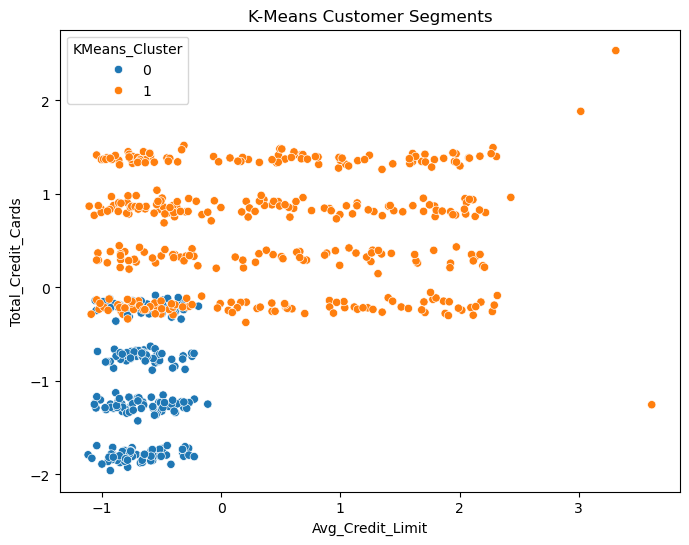

In [17]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=scaled_df, x="Avg_Credit_Limit", y="Total_Credit_Cards", hue="KMeans_Cluster"
)

plt.title("K-Means Customer Segments")
plt.show()

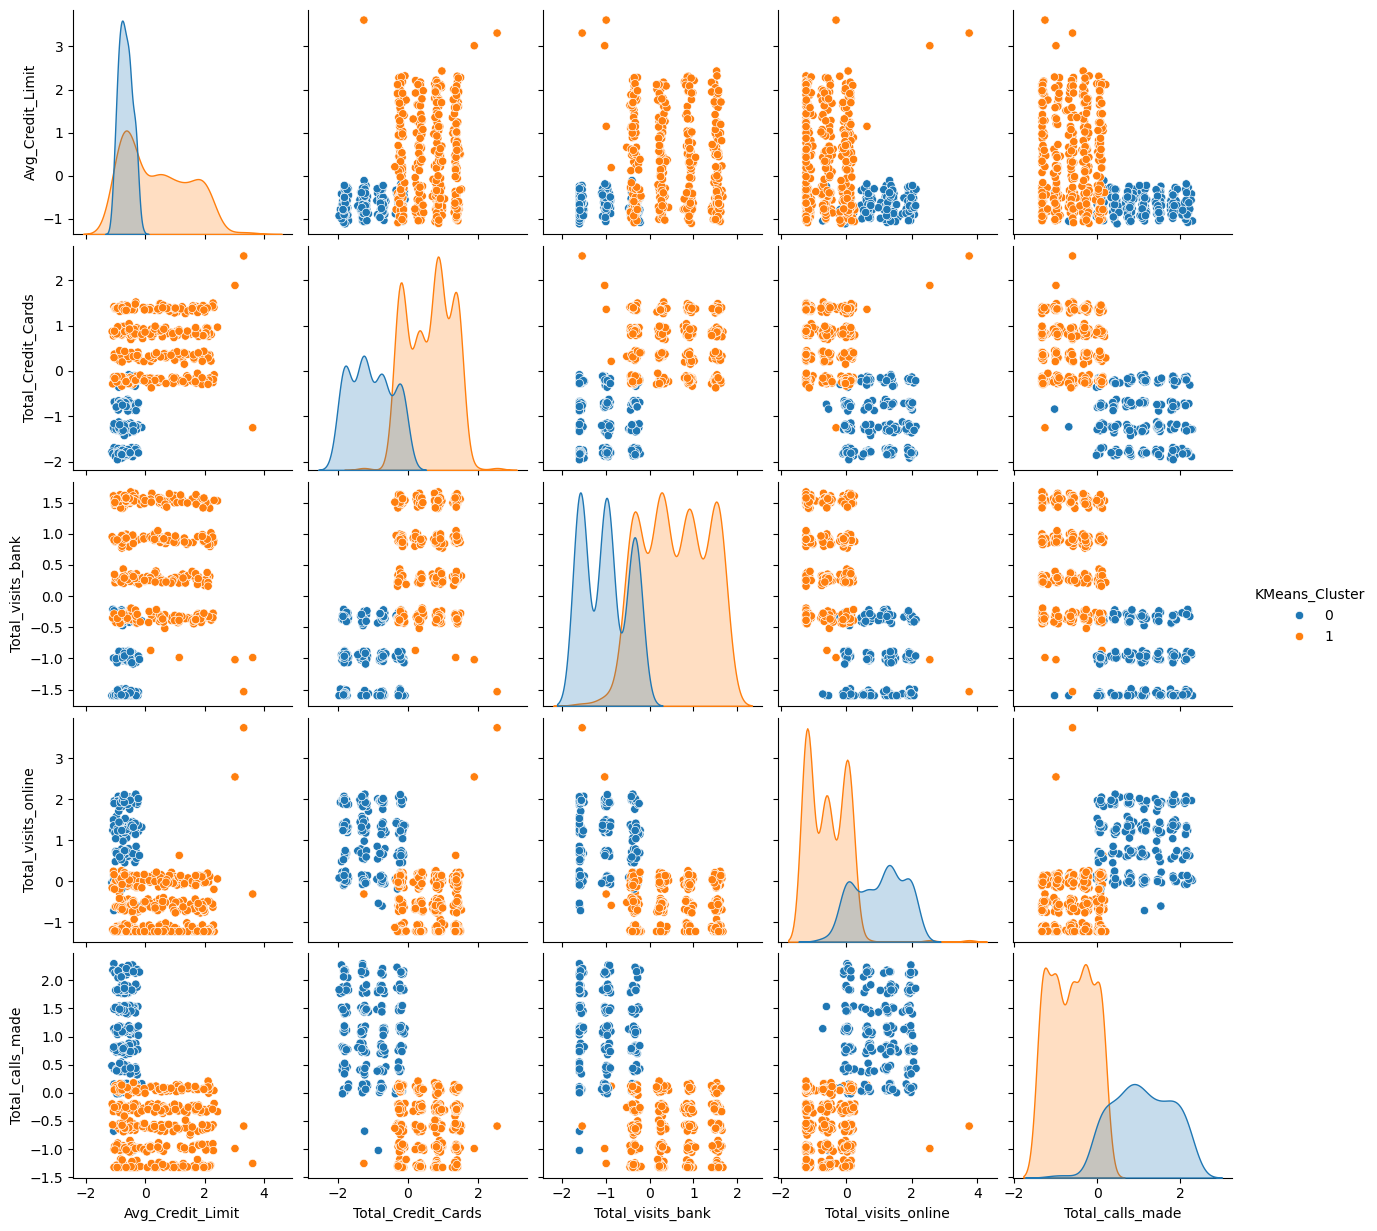

In [18]:
sns.pairplot(scaled_df, hue="KMeans_Cluster")

plt.show()

In [19]:
# Hierarchical (Agglomerative) Clustering

hierarchical = AgglomerativeClustering(n_clusters=2)

hierarchical_labels = hierarchical.fit_predict(
    scaled_df.drop(columns=["KMeans_Cluster"])
)

scaled_df["Hierarchical_Cluster"] = hierarchical_labels

scaled_df["Hierarchical_Cluster"].value_counts()

Hierarchical_Cluster
0    387
1    224
Name: count, dtype: int64

In [20]:
hierarchical_silhouette = silhouette_score(
    scaled_df.drop(columns=["KMeans_Cluster", "Hierarchical_Cluster"]),
    hierarchical_labels,
)

hierarchical_davies = davies_bouldin_score(
    scaled_df.drop(columns=["KMeans_Cluster", "Hierarchical_Cluster"]),
    hierarchical_labels,
)

print("Silhouette Score:", hierarchical_silhouette)
print("Davies-Bouldin Score:", hierarchical_davies)

Silhouette Score: 0.47657668421035304
Davies-Bouldin Score: 0.821664924859721


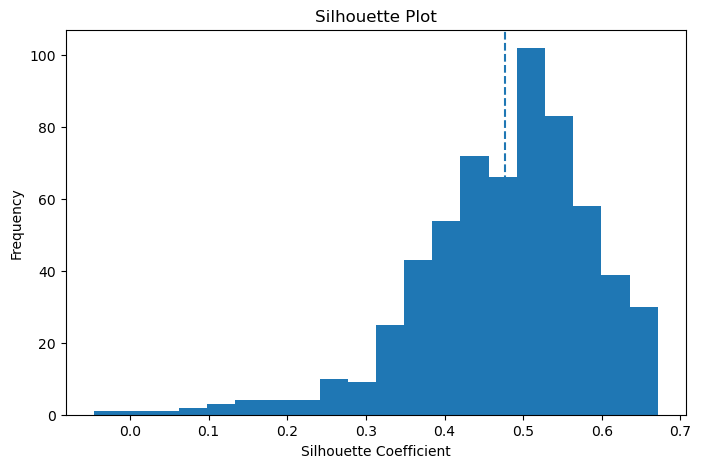

In [23]:
sample_silhouette_values = silhouette_samples(
    scaled_df.drop(columns=["KMeans_Cluster", "Hierarchical_Cluster"]), kmeans_labels
)

plt.figure(figsize=(8, 5))

plt.hist(sample_silhouette_values, bins=20)

plt.axvline(sample_silhouette_values.mean(), linestyle="--")

plt.title("Silhouette Plot")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Frequency")

plt.show()

The silhouette plot showed that most observations had positive silhouette coefficients, indicating that customers were generally assigned to appropriate clusters. Most values were concentrated between 0.4 and 0.6, suggesting moderate to strong cluster separation. Only a small number of observations had coefficients near zero or slightly negative, indicating minimal overlap between customer segments.

## Discussion

 How well did K-Means and Hierarchical Clustering segment the data?

K-Means and Hierarchical Clustering both segmented the credit card customers well. The best number of clusters was 2 based on the evaluation scores. K-Means had a silhouette score of about 0.477 and a Davies-Bouldin score of about 0.820. Hierarchical Clustering had almost the same results, with a silhouette score of about 0.477 and a Davies-Bouldin score of about 0.822. This shows that both models found very similar customer groups.

What challenges did you encounter in feature scaling and outlier detection?

One challenge was that the dataset had features on very different scales. For example, average credit limit was much larger than the number of credit cards, visits, or calls. Because of this, StandardScaler was needed so one column would not dominate the clustering. For outlier detection, the IQR method removed 49 rows, which was reasonable because the dataset still had 611 rows after cleaning.

How do silhouette and Davies-Bouldin scores help in cluster evaluation?

Silhouette score helps show how well each customer fits inside its assigned cluster compared to other clusters. A higher silhouette score is better. Davies-Bouldin score measures how separated and compact the clusters are, and a lower score is better. These scores helped choose 2 clusters for the credit card dataset instead of guessing based only on the elbow graph.